In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import skew

In [30]:
df=pd.read_csv("./datos.csv",header=None,names=['Datos'])
df

,Datos
0,68
1,73
2,61
3,66
4,96
...,...
76,71
77,75
78,74
79,77


In [31]:
mediana = df['Datos'].median()
print(f"Mediana: {mediana:.2f}")

Mediana: 75.00


In [32]:
moda = df['Datos'].mode()[0]
veces= (df['Datos']==moda).sum()
print(moda,' ',veces)

75   7


In [33]:
q1 = df['Datos'].quantile(.25) # Primer cuartil (25%)
q2 = df['Datos'].quantile(.50)   # Segundo cuartil (50%) = mediana
q3 = df['Datos'].quantile(.75)  # Tercer cuartil (75%)
print(f"Q1 (25%): {q1:.2f}")
print(f"Q2 (50%): {q2:.2f}")  # Igual que la mediana
print(f"Q3 (75%): {q3:.2f}")

Q1 (25%): 68.00
Q2 (50%): 75.00
Q3 (75%): 82.00


In [34]:
iqr = q3 - q1
print(f"IQR: {iqr:.2f}")

IQR: 14.00


In [35]:
varianza = df['Datos'].var()
print(f"Varianza: {varianza:.2f}") 

Varianza: 106.29


In [36]:
desviacion_std = df['Datos'].std()
print(f"Desviación Estándar:{desviacion_std:.2f}")

Desviación Estándar:10.31


In [37]:
rango = df['Datos'].max() - df['Datos'].min()
print(f"Rango: {rango:.2f}")

Rango: 44.00


In [38]:
media = df['Datos'].mean()
print(f"Media: {media:.2f}")

Media: 75.26


In [39]:
cv = (desviacion_std / media) * 100
print(f" COEFICIENTE DE VARIACIÓN: {cv:.1f}%")
print(f"  (Indica que la variabilidad es {'alta' if cv > 30 else 'moderada' if cv > 15 else 'baja'})")

 COEFICIENTE DE VARIACIÓN: 13.7%
  (Indica que la variabilidad es baja)


In [40]:
asimetria = skew(np.array(df['Datos']))
print(f"ASIMETRÍA: {asimetria:.2f}")
if asimetria > 0.5:
    print("  Distribución con sesgo positivo (cola a la derecha)")
elif asimetria < -0.5:
    print("  Distribución con sesgo negativo (cola a la izquierda)")
else:
    print("  Distribución aproximadamente simétrica")

ASIMETRÍA: 0.17
  Distribución aproximadamente simétrica


In [41]:
datos=np.array(df['Datos'])
percentiles = [10, 25, 50, 75, 90]
valores_percentiles = np.percentile(datos, percentiles)

print("PERCENTILES CLAVE:")
for p, v in zip(percentiles, valores_percentiles):
    print(f"  P{p}: {v:.2f}")

# Identificar días atípicos (outliers)
limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr
outliers = datos[(datos < limite_inferior) | (datos > limite_superior)]

print(f" Datos ATÍPICOS:")
print(f"  Límite inferior: {limite_inferior:.2f}")
print(f"  Límite superior: {limite_superior:.2f}")
if len(outliers) > 0:
    print(f"  Días atípicos: {outliers}")
else:
    print("  No se detectaron datos atípicos")

# Interpretación gerencial
print("INTERPRETACIÓN PARA LOS DATOS:")
print(f"  1. Datos pormedio: {media:.2f}")
print(f"  2. Datos típicos: entre {q1:.2f} y {q3:.2f} (50% de los datos)")
print(f"  3. Variabilidad: ±${desviacion_std:.2f} del promedio")
print(f"  4. Los datos superiores a {limite_superior:.2f} son grandes")
print(f"  5. Los datos inferiores a {limite_inferior:.2f} requieren análisis")

PERCENTILES CLAVE:
  P10: 62.00
  P25: 68.00
  P50: 75.00
  P75: 82.00
  P90: 89.00
 Datos ATÍPICOS:
  Límite inferior: 47.00
  Límite superior: 103.00
  No se detectaron datos atípicos
INTERPRETACIÓN PARA LOS DATOS:
  1. Datos pormedio: 75.26
  2. Datos típicos: entre 68.00 y 82.00 (50% de los datos)
  3. Variabilidad: ±$10.31 del promedio
  4. Los datos superiores a 103.00 son grandes
  5. Los datos inferiores a 47.00 requieren análisis


/tmp/ipykernel_10031/3286767152.py:16: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[0, 1].boxplot(datos, vert=False)


Text(0.5, 1.0, 'Resumen Estadístico')

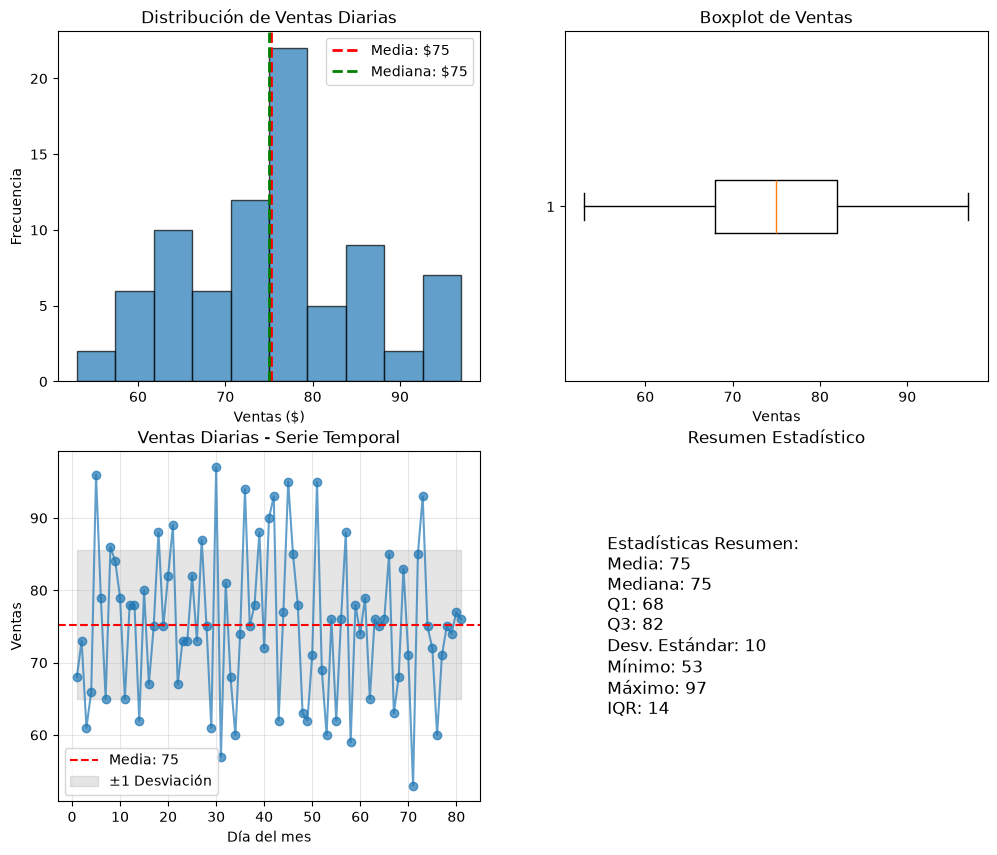

In [46]:
import matplotlib.pyplot as plt

# Crear figura con varios subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Histograma con medidas de tendencia central
axes[0, 0].hist(datos, bins=10, edgecolor='black', alpha=0.7)
axes[0, 0].axvline(media, color='red', linestyle='dashed', linewidth=2, label=f'Media: ${media:.0f}')
axes[0, 0].axvline(mediana, color='green', linestyle='dashed', linewidth=2, label=f'Mediana: ${mediana:.0f}')
axes[0, 0].set_title('Distribución de Ventas Diarias')
axes[0, 0].set_xlabel('Ventas ($)')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].legend()

# Boxplot
axes[0, 1].boxplot(datos, vert=False)
axes[0, 1].set_title('Boxplot de Ventas')
axes[0, 1].set_xlabel('Ventas')

# Serie temporal
dias = np.arange(1, len(datos) + 1)  # Genera 81 días (de 1 a 81)
axes[1, 0].plot(dias, datos, marker='o', linestyle='-', alpha=0.7)
axes[1, 0].axhline(media, color='red', linestyle='--', label=f'Media: {media:.0f}')
axes[1, 0].fill_between(dias, media - desviacion_std, media + desviacion_std, 
                        alpha=0.2, color='gray', label='±1 Desviación')
axes[1, 0].set_title('Ventas Diarias - Serie Temporal')
axes[1, 0].set_xlabel('Día del mes')
axes[1, 0].set_ylabel('Ventas')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Resumen estadístico
stats_text = f"""
Estadísticas Resumen:
Media: {media:.0f}
Mediana: {mediana:.0f}
Q1: {q1:.0f}
Q3: {q3:.0f}
Desv. Estándar: {desviacion_std:.0f}
Mínimo: {np.min(datos):.0f}
Máximo: {np.max(datos):.0f}
IQR: {iqr:.0f}
"""
axes[1, 1].text(0.1, 0.5, stats_text, transform=axes[1, 1].transAxes,
                fontsize=12, verticalalignment='center')
axes[1, 1].axis('off')
axes[1, 1].set_title('Resumen Estadístico')